# KAN Benchmarking: Player Injuries Impact Dataset (Real Data)

This notebook benchmarks KAN architectures on **real Premier League injury data**.

## Prediction Task
Predict whether a player's post-injury performance will be **better or worse** than pre-injury based on:
- Player attributes (age, FIFA rating, position)
- Pre-injury match performance (ratings, team results)
- Injury characteristics

## Models Tested:
- **Baselines**: XGBoost, MLP, LSTM
- **KAN Variants**: efficient-kan, FastKAN, FourierKAN, ChebyKAN, Wav-KAN

In [1]:
# Core imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

# ML imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
import xgboost as xgb

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Set seeds
np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: mps


## 1. Data Loading & Preprocessing

In [2]:
# Load dataset
df = pd.read_csv('../data/player_injuries_impact.csv')
print(f"Original dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()[:10]}...")
df.head()

Original dataset shape: (656, 42)

Columns: ['Name', 'Team Name', 'Position', 'Age', 'Season', 'FIFA rating', 'Injury', 'Date of Injury', 'Date of return', 'Match1_before_injury_Result']...


,Name,Team Name,Position,Age,Season,FIFA rating,Injury,Date of Injury,Date of return,Match1_before_injury_Result,...,Match1_after_injury_GD,Match1_after_injury_Player_rating,Match2_after_injury_Result,Match2_after_injury_Opposition,Match2_after_injury_GD,Match2_after_injury_Player_rating,Match3_after_injury_Result,Match3_after_injury_Opposition,Match3_after_injury_GD,Match3_after_injury_Player_rating
0,Jamaal Lascelles,Newcastle,Center Back,26,2019/20,77,Knee injury,"Nov 9, 2019","Jan 13, 2020",draw,...,1,7.1,draw,Everton,0,6.2,draw,Norwich City,0,6.7
1,Fabian Schär,Newcastle,Center Back,28,2019/20,79,Knee injury,"Oct 20, 2019","Nov 24, 2019",lose,...,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.
2,Fabian Schär,Newcastle,Center Back,28,2019/20,79,Hamstring strain,"Jan 2, 2020","Jan 17, 2020",lose,...,0,6(S),lose,Arsenal,-4,N.A.,lose,Crystal Palace,-1,6.5
3,Fabian Schär,Newcastle,Center Back,28,2019/20,79,Shoulder injury,"Jul 16, 2020","Sep 28, 2020",lose,...,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.
4,Paul Dummett,Newcastle,Center Back,28,2019/20,75,Groin injury,"Dec 22, 2019","Jan 10, 2020",win,...,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.,N.A.


In [3]:
def parse_player_rating(rating_str):
    """Parse player rating, handling '6.5(S)' format and 'N.A.' values."""
    if pd.isna(rating_str) or rating_str == 'N.A.':
        return np.nan
    rating_str = str(rating_str).replace('(S)', '').strip()
    try:
        return float(rating_str)
    except:
        return np.nan

def parse_goal_difference(gd_str):
    """Parse goal difference, handling 'N.A.' values."""
    if pd.isna(gd_str) or gd_str == 'N.A.':
        return np.nan
    try:
        return float(gd_str)
    except:
        return np.nan

def result_to_points(result):
    """Convert match result to points."""
    if pd.isna(result) or result == 'N.A.':
        return np.nan
    result = str(result).lower()
    if result == 'win':
        return 3
    elif result == 'draw':
        return 1
    else:
        return 0

In [4]:
# Feature Engineering
print("Engineering features...")

# Parse all rating columns
rating_cols_before = ['Match1_before_injury_Player_rating', 'Match2_before_injury_Player_rating', 'Match3_before_injury_Player_rating']
rating_cols_after = ['Match1_after_injury_Player_rating', 'Match2_after_injury_Player_rating', 'Match3_after_injury_Player_rating']

for col in rating_cols_before + rating_cols_after:
    df[col + '_parsed'] = df[col].apply(parse_player_rating)

# Parse goal difference columns
gd_cols_before = ['Match1_before_injury_GD', 'Match2_before_injury_GD', 'Match3_before_injury_GD']
gd_cols_after = ['Match1_after_injury_GD', 'Match2_after_injury_GD', 'Match3_after_injury_GD']

for col in gd_cols_before + gd_cols_after:
    df[col + '_parsed'] = df[col].apply(parse_goal_difference)

# Parse result columns to points
result_cols_before = ['Match1_before_injury_Result', 'Match2_before_injury_Result', 'Match3_before_injury_Result']
result_cols_after = ['Match1_after_injury_Result', 'Match2_after_injury_Result', 'Match3_after_injury_Result']

for col in result_cols_before + result_cols_after:
    df[col + '_points'] = df[col].apply(result_to_points)

# Calculate average performance before injury
df['avg_rating_before'] = df[[c + '_parsed' for c in rating_cols_before]].mean(axis=1, skipna=True)
df['avg_gd_before'] = df[[c + '_parsed' for c in gd_cols_before]].mean(axis=1, skipna=True)
df['avg_points_before'] = df[[c + '_points' for c in result_cols_before]].mean(axis=1, skipna=True)

# Calculate average performance after injury
df['avg_rating_after'] = df[[c + '_parsed' for c in rating_cols_after]].mean(axis=1, skipna=True)
df['avg_gd_after'] = df[[c + '_parsed' for c in gd_cols_after]].mean(axis=1, skipna=True)
df['avg_points_after'] = df[[c + '_points' for c in result_cols_after]].mean(axis=1, skipna=True)

print(f"Created aggregate features")

Engineering features...


Created aggregate features


In [5]:
# Create target: Did player perform better after injury than before?
# 1 = performance improved or maintained, 0 = performance declined

df['rating_change'] = df['avg_rating_after'] - df['avg_rating_before']
df['target'] = (df['rating_change'] >= 0).astype(int)

# Filter to rows with valid target
df_clean = df.dropna(subset=['target', 'avg_rating_before', 'avg_rating_after'])
print(f"Rows with valid data: {len(df_clean)} / {len(df)}")
print(f"\nTarget distribution:")
print(df_clean['target'].value_counts())

Rows with valid data: 503 / 656

Target distribution:
target
0    253
1    250
Name: count, dtype: int64


In [6]:
# Encode categorical features
le_position = LabelEncoder()
le_team = LabelEncoder()
le_injury = LabelEncoder()
le_season = LabelEncoder()

df_clean['Position_encoded'] = le_position.fit_transform(df_clean['Position'])
df_clean['Team_encoded'] = le_team.fit_transform(df_clean['Team Name'])
df_clean['Injury_encoded'] = le_injury.fit_transform(df_clean['Injury'].str.lower())
df_clean['Season_encoded'] = le_season.fit_transform(df_clean['Season'])

# Select features for modeling
feature_cols = [
    'Age', 'FIFA rating', 'Position_encoded', 'Team_encoded', 'Injury_encoded', 'Season_encoded',
    'avg_rating_before', 'avg_gd_before', 'avg_points_before'
]

X = df_clean[feature_cols].values
y = df_clean['target'].values

print(f"\nFeature matrix shape: {X.shape}")
print(f"Features: {feature_cols}")


Feature matrix shape: (503, 9)
Features: ['Age', 'FIFA rating', 'Position_encoded', 'Team_encoded', 'Injury_encoded', 'Season_encoded', 'avg_rating_before', 'avg_gd_before', 'avg_points_before']


In [7]:
# Split and scale
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train_scaled.shape}, Val: {X_val_scaled.shape}, Test: {X_test_scaled.shape}")

# Convert to PyTorch tensors
X_train_t = torch.FloatTensor(X_train_scaled)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1)
X_val_t = torch.FloatTensor(X_val_scaled)
y_val_t = torch.FloatTensor(y_val).unsqueeze(1)
X_test_t = torch.FloatTensor(X_test_scaled)
y_test_t = torch.FloatTensor(y_test).unsqueeze(1)

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

n_features = X_train_scaled.shape[1]

Train: (352, 9), Val: (75, 9), Test: (76, 9)


## 2. Model Definitions & Training Functions

In [8]:
results = []

def evaluate_model(model_name, y_true, y_pred, y_prob, train_time, inference_time, n_params):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    try:
        auc = roc_auc_score(y_true, y_prob)
    except:
        auc = 0.5
    
    result = {
        'Model': model_name,
        'Accuracy': acc,
        'F1 Score': f1,
        'AUC-ROC': auc,
        'Train Time (s)': train_time,
        'Inference Time (ms)': inference_time * 1000,
        'Parameters': n_params
    }
    results.append(result)
    print(f"\n{model_name}:")
    print(f"  Accuracy: {acc:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}")
    print(f"  Train: {train_time:.2f}s, Inference: {inference_time*1000:.2f}ms, Params: {n_params:,}")
    return result

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims=[64, 32]):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h_dim in hidden_dims:
            layers.extend([nn.Linear(prev_dim, h_dim), nn.ReLU(), nn.Dropout(0.2)])
            prev_dim = h_dim
        layers.extend([nn.Linear(prev_dim, 1), nn.Sigmoid()])
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

class LSTMClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        x = x.unsqueeze(1)
        lstm_out, _ = self.lstm(x)
        return self.sigmoid(self.fc(lstm_out[:, -1, :]))

def train_pytorch_model(model, train_loader, X_val_t, y_val_t, epochs=100, lr=0.001):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCELoss()
    
    start_time = time.time()
    for epoch in range(epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
    return time.time() - start_time

def evaluate_pytorch_model(model, X_test_t, y_test):
    model.eval()
    model = model.to(device)
    start_time = time.time()
    with torch.no_grad():
        y_prob = model(X_test_t.to(device)).cpu().numpy().flatten()
    inference_time = time.time() - start_time
    y_pred = (y_prob > 0.5).astype(int)
    n_params = sum(p.numel() for p in model.parameters())
    return y_pred, y_prob, inference_time, n_params

## 3. Baseline Models

In [9]:
# XGBoost
print("Training XGBoost...")
start_time = time.time()
xgb_model = xgb.XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train_scaled, y_train)
train_time_xgb = time.time() - start_time

start_time = time.time()
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]
inference_time_xgb = time.time() - start_time

n_params_xgb = sum(tree.count('[') for tree in xgb_model.get_booster().get_dump())
evaluate_model('XGBoost', y_test, y_pred_xgb, y_prob_xgb, train_time_xgb, inference_time_xgb, n_params_xgb)

Training XGBoost...



XGBoost:
  Accuracy: 0.7105, F1: 0.6944, AUC: 0.7403
  Train: 0.15s, Inference: 1.54ms, Params: 2,016


{'Model': 'XGBoost',
 'Accuracy': 0.7105263157894737,
 'F1 Score': 0.6944444444444444,
 'AUC-ROC': 0.7403047091412742,
 'Train Time (s)': 0.14589905738830566,
 'Inference Time (ms)': 1.5380382537841797,
 'Parameters': 2016}

In [10]:
# MLP
print("Training MLP...")
mlp_model = MLP(n_features, hidden_dims=[64, 32])
train_time_mlp = train_pytorch_model(mlp_model, train_loader, X_val_t, y_val_t, epochs=100)
y_pred_mlp, y_prob_mlp, inference_time_mlp, n_params_mlp = evaluate_pytorch_model(mlp_model, X_test_t, y_test)
evaluate_model('MLP', y_test, y_pred_mlp, y_prob_mlp, train_time_mlp, inference_time_mlp, n_params_mlp)

Training MLP...



MLP:
  Accuracy: 0.6316, F1: 0.6111, AUC: 0.7458
  Train: 3.28s, Inference: 9.44ms, Params: 2,753


{'Model': 'MLP',
 'Accuracy': 0.631578947368421,
 'F1 Score': 0.6111111111111112,
 'AUC-ROC': 0.7458448753462604,
 'Train Time (s)': 3.279853105545044,
 'Inference Time (ms)': 9.44375991821289,
 'Parameters': 2753}

In [11]:
# LSTM
print("Training LSTM...")
lstm_model = LSTMClassifier(n_features, hidden_dim=64)
train_time_lstm = train_pytorch_model(lstm_model, train_loader, X_val_t, y_val_t, epochs=100)
y_pred_lstm, y_prob_lstm, inference_time_lstm, n_params_lstm = evaluate_pytorch_model(lstm_model, X_test_t, y_test)
evaluate_model('LSTM', y_test, y_pred_lstm, y_prob_lstm, train_time_lstm, inference_time_lstm, n_params_lstm)

Training LSTM...



LSTM:
  Accuracy: 0.6579, F1: 0.6486, AUC: 0.7555
  Train: 3.60s, Inference: 6.22ms, Params: 19,265


{'Model': 'LSTM',
 'Accuracy': 0.6578947368421053,
 'F1 Score': 0.6486486486486487,
 'AUC-ROC': 0.7555401662049861,
 'Train Time (s)': 3.6002309322357178,
 'Inference Time (ms)': 6.218910217285156,
 'Parameters': 19265}

## 4. KAN Implementations

In [12]:
# efficient-kan
try:
    from efficient_kan import KAN as EfficientKAN
    
    class EfficientKANClassifier(nn.Module):
        def __init__(self, layers_hidden):
            super().__init__()
            self.kan = EfficientKAN(layers_hidden)
            self.sigmoid = nn.Sigmoid()
        def forward(self, x):
            return self.sigmoid(self.kan(x))
    
    print("Training efficient-kan...")
    efficient_kan = EfficientKANClassifier([n_features, 16, 8, 1])
    train_time_ekan = train_pytorch_model(efficient_kan, train_loader, X_val_t, y_val_t, epochs=100)
    y_pred_ekan, y_prob_ekan, inference_time_ekan, n_params_ekan = evaluate_pytorch_model(efficient_kan, X_test_t, y_test)
    evaluate_model('efficient-kan', y_test, y_pred_ekan, y_prob_ekan, train_time_ekan, inference_time_ekan, n_params_ekan)
except Exception as e:
    print(f"efficient-kan failed: {e}")

Training efficient-kan...



efficient-kan:
  Accuracy: 0.6316, F1: 0.6111, AUC: 0.6503
  Train: 6.37s, Inference: 32.02ms, Params: 2,800


In [13]:
# FastKAN (RBF-based)
class RBFKANLayer(nn.Module):
    def __init__(self, in_features, out_features, num_bases=8):
        super().__init__()
        self.centers = nn.Parameter(torch.linspace(-2, 2, num_bases).repeat(in_features, out_features, 1))
        self.widths = nn.Parameter(torch.ones(in_features, out_features, num_bases) * 0.5)
        self.weights = nn.Parameter(torch.randn(in_features, out_features, num_bases) * 0.1)
    
    def forward(self, x):
        x = x.unsqueeze(2).unsqueeze(3)
        rbf = torch.exp(-((x - self.centers) ** 2) / (2 * self.widths ** 2 + 1e-8))
        return (rbf * self.weights).sum(dim=-1).sum(dim=1)

class FastKAN(nn.Module):
    def __init__(self, layers_dims, num_bases=8):
        super().__init__()
        self.layers = nn.ModuleList([RBFKANLayer(layers_dims[i], layers_dims[i+1], num_bases) for i in range(len(layers_dims)-1)])
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return self.sigmoid(x)

print("Training FastKAN (RBF)...")
fast_kan = FastKAN([n_features, 16, 8, 1], num_bases=8)
train_time_fkan = train_pytorch_model(fast_kan, train_loader, X_val_t, y_val_t, epochs=100, lr=0.005)
y_pred_fkan, y_prob_fkan, inference_time_fkan, n_params_fkan = evaluate_pytorch_model(fast_kan, X_test_t, y_test)
evaluate_model('FastKAN (RBF)', y_test, y_pred_fkan, y_prob_fkan, train_time_fkan, inference_time_fkan, n_params_fkan)

Training FastKAN (RBF)...



FastKAN (RBF):
  Accuracy: 0.5395, F1: 0.5070, AUC: 0.5596
  Train: 4.47s, Inference: 27.13ms, Params: 6,720


{'Model': 'FastKAN (RBF)',
 'Accuracy': 0.5394736842105263,
 'F1 Score': 0.5070422535211268,
 'AUC-ROC': 0.5595567867036011,
 'Train Time (s)': 4.469624757766724,
 'Inference Time (ms)': 27.127742767333984,
 'Parameters': 6720}

In [14]:
# FourierKAN
class FourierKANLayer(nn.Module):
    def __init__(self, in_features, out_features, num_frequencies=4):
        super().__init__()
        self.a_coeffs = nn.Parameter(torch.randn(in_features, out_features, num_frequencies) * 0.1)
        self.b_coeffs = nn.Parameter(torch.randn(in_features, out_features, num_frequencies) * 0.1)
        self.frequencies = nn.Parameter(torch.arange(1, num_frequencies + 1).float().repeat(in_features, out_features, 1))
    
    def forward(self, x):
        x = x.unsqueeze(2).unsqueeze(3)
        cos_terms = torch.cos(self.frequencies * x * np.pi)
        sin_terms = torch.sin(self.frequencies * x * np.pi)
        return (self.a_coeffs * cos_terms + self.b_coeffs * sin_terms).sum(dim=-1).sum(dim=1)

class FourierKAN(nn.Module):
    def __init__(self, layers_dims, num_frequencies=4):
        super().__init__()
        self.layers = nn.ModuleList([FourierKANLayer(layers_dims[i], layers_dims[i+1], num_frequencies) for i in range(len(layers_dims)-1)])
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return self.sigmoid(x)

print("Training FourierKAN...")
fourier_kan = FourierKAN([n_features, 16, 8, 1], num_frequencies=4)
train_time_fourierkan = train_pytorch_model(fourier_kan, train_loader, X_val_t, y_val_t, epochs=100, lr=0.005)
y_pred_fourierkan, y_prob_fourierkan, inference_time_fourierkan, n_params_fourierkan = evaluate_pytorch_model(fourier_kan, X_test_t, y_test)
evaluate_model('FourierKAN', y_test, y_pred_fourierkan, y_prob_fourierkan, train_time_fourierkan, inference_time_fourierkan, n_params_fourierkan)

Training FourierKAN...



FourierKAN:
  Accuracy: 0.4342, F1: 0.3768, AUC: 0.4751
  Train: 5.14s, Inference: 10.89ms, Params: 3,360


{'Model': 'FourierKAN',
 'Accuracy': 0.4342105263157895,
 'F1 Score': 0.37681159420289856,
 'AUC-ROC': 0.47506925207756234,
 'Train Time (s)': 5.14147424697876,
 'Inference Time (ms)': 10.893821716308594,
 'Parameters': 3360}

In [15]:
# ChebyKAN
class ChebyKANLayer(nn.Module):
    def __init__(self, in_features, out_features, degree=4):
        super().__init__()
        self.degree = degree
        self.coeffs = nn.Parameter(torch.randn(in_features, out_features, degree + 1) * 0.1)
    
    def forward(self, x):
        x_norm = torch.tanh(x)
        x_norm = x_norm.unsqueeze(2)
        cheby = [torch.ones_like(x_norm), x_norm]
        for _ in range(2, self.degree + 1):
            cheby.append(2 * x_norm * cheby[-1] - cheby[-2])
        cheby = torch.stack(cheby, dim=-1)
        return (cheby * self.coeffs).sum(dim=-1).sum(dim=1)

class ChebyKAN(nn.Module):
    def __init__(self, layers_dims, degree=4):
        super().__init__()
        self.layers = nn.ModuleList([ChebyKANLayer(layers_dims[i], layers_dims[i+1], degree) for i in range(len(layers_dims)-1)])
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return self.sigmoid(x)

print("Training ChebyKAN...")
cheby_kan = ChebyKAN([n_features, 16, 8, 1], degree=4)
train_time_chebykan = train_pytorch_model(cheby_kan, train_loader, X_val_t, y_val_t, epochs=100, lr=0.005)
y_pred_chebykan, y_prob_chebykan, inference_time_chebykan, n_params_chebykan = evaluate_pytorch_model(cheby_kan, X_test_t, y_test)
evaluate_model('ChebyKAN', y_test, y_pred_chebykan, y_prob_chebykan, train_time_chebykan, inference_time_chebykan, n_params_chebykan)

Training ChebyKAN...



ChebyKAN:
  Accuracy: 0.6184, F1: 0.6329, AUC: 0.6807
  Train: 3.56s, Inference: 25.47ms, Params: 1,400


{'Model': 'ChebyKAN',
 'Accuracy': 0.618421052631579,
 'F1 Score': 0.6329113924050633,
 'AUC-ROC': 0.6807479224376731,
 'Train Time (s)': 3.564631938934326,
 'Inference Time (ms)': 25.466203689575195,
 'Parameters': 1400}

In [16]:
# Wav-KAN
class WaveletKANLayer(nn.Module):
    def __init__(self, in_features, out_features, num_wavelets=8):
        super().__init__()
        self.translations = nn.Parameter(torch.linspace(-2, 2, num_wavelets).repeat(in_features, out_features, 1))
        self.scales = nn.Parameter(torch.ones(in_features, out_features, num_wavelets) * 0.5)
        self.weights = nn.Parameter(torch.randn(in_features, out_features, num_wavelets) * 0.1)
    
    def mexican_hat(self, x):
        return (1 - x**2) * torch.exp(-x**2 / 2)
    
    def forward(self, x):
        x = x.unsqueeze(2).unsqueeze(3)
        x_norm = (x - self.translations) / (self.scales + 1e-8)
        return (self.mexican_hat(x_norm) * self.weights).sum(dim=-1).sum(dim=1)

class WavKAN(nn.Module):
    def __init__(self, layers_dims, num_wavelets=8):
        super().__init__()
        self.layers = nn.ModuleList([WaveletKANLayer(layers_dims[i], layers_dims[i+1], num_wavelets) for i in range(len(layers_dims)-1)])
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return self.sigmoid(x)

print("Training Wav-KAN...")
wav_kan = WavKAN([n_features, 16, 8, 1], num_wavelets=8)
train_time_wavkan = train_pytorch_model(wav_kan, train_loader, X_val_t, y_val_t, epochs=100, lr=0.005)
y_pred_wavkan, y_prob_wavkan, inference_time_wavkan, n_params_wavkan = evaluate_pytorch_model(wav_kan, X_test_t, y_test)
evaluate_model('Wav-KAN', y_test, y_pred_wavkan, y_prob_wavkan, train_time_wavkan, inference_time_wavkan, n_params_wavkan)

Training Wav-KAN...



Wav-KAN:
  Accuracy: 0.5789, F1: 0.5897, AUC: 0.5651
  Train: 3.78s, Inference: 3.03ms, Params: 6,720


{'Model': 'Wav-KAN',
 'Accuracy': 0.5789473684210527,
 'F1 Score': 0.5897435897435898,
 'AUC-ROC': 0.5650969529085872,
 'Train Time (s)': 3.7819321155548096,
 'Inference Time (ms)': 3.0260086059570312,
 'Parameters': 6720}

## 5. Results Summary

In [17]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Accuracy', ascending=False)

print("\n" + "="*80)
print("BENCHMARK RESULTS - Player Injuries Impact Dataset (Real Data)")
print("="*80)
display(results_df.round(4))


BENCHMARK RESULTS - Player Injuries Impact Dataset (Real Data)


,Model,Accuracy,F1 Score,AUC-ROC,Train Time (s),Inference Time (ms),Parameters
0,XGBoost,0.7105,0.6944,0.7403,0.1459,1.5380,2016
2,LSTM,0.6579,0.6486,0.7555,3.6002,6.2189,19265
1,MLP,0.6316,0.6111,0.7458,3.2799,9.4438,2753
3,efficient-kan,0.6316,0.6111,0.6503,6.3660,32.0191,2800
6,ChebyKAN,0.6184,0.6329,0.6807,3.5646,25.4662,1400
7,Wav-KAN,0.5789,0.5897,0.5651,3.7819,3.0260,6720
4,FastKAN (RBF),0.5395,0.5070,0.5596,4.4696,27.1277,6720
5,FourierKAN,0.4342,0.3768,0.4751,5.1415,10.8938,3360


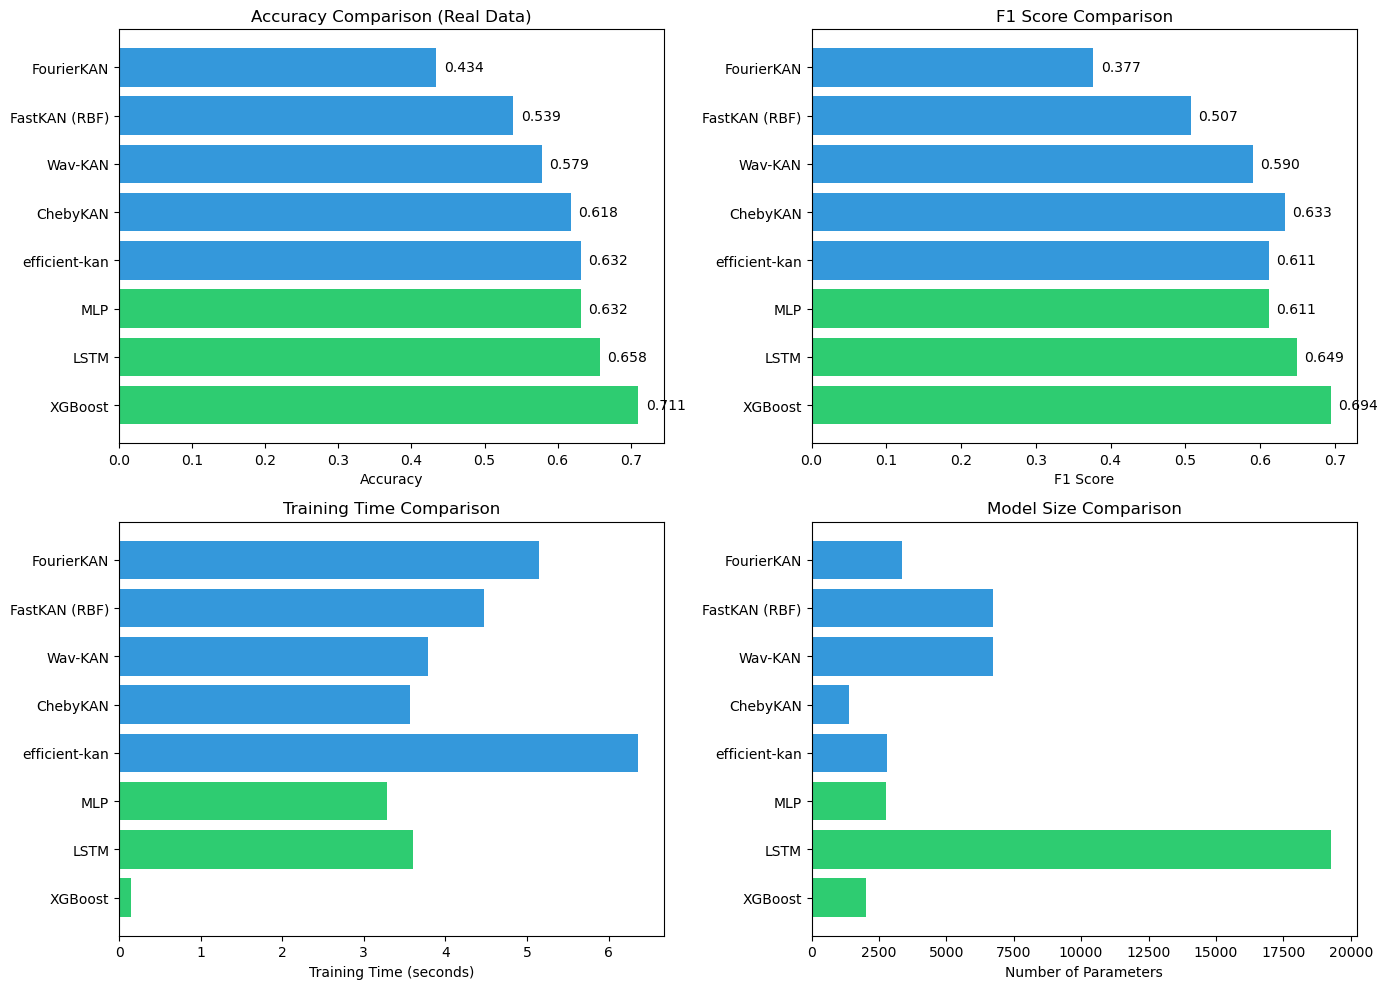


🟢 Green = Baseline models | 🔵 Blue = KAN variants


In [18]:
# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

colors = ['#2ecc71' if m in ['XGBoost', 'MLP', 'LSTM'] else '#3498db' for m in results_df['Model']]

ax1 = axes[0, 0]
bars = ax1.barh(results_df['Model'], results_df['Accuracy'], color=colors)
ax1.set_xlabel('Accuracy')
ax1.set_title('Accuracy Comparison (Real Data)')
for bar, val in zip(bars, results_df['Accuracy']):
    ax1.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center')

ax2 = axes[0, 1]
bars = ax2.barh(results_df['Model'], results_df['F1 Score'], color=colors)
ax2.set_xlabel('F1 Score')
ax2.set_title('F1 Score Comparison')
for bar, val in zip(bars, results_df['F1 Score']):
    ax2.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center')

ax3 = axes[1, 0]
bars = ax3.barh(results_df['Model'], results_df['Train Time (s)'], color=colors)
ax3.set_xlabel('Training Time (seconds)')
ax3.set_title('Training Time Comparison')

ax4 = axes[1, 1]
bars = ax4.barh(results_df['Model'], results_df['Parameters'], color=colors)
ax4.set_xlabel('Number of Parameters')
ax4.set_title('Model Size Comparison')

plt.tight_layout()
plt.savefig('../figures/benchmark_results_real.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n🟢 Green = Baseline models | 🔵 Blue = KAN variants")

In [19]:
print("\n" + "="*80)
print("KEY FINDINGS - REAL DATA")
print("="*80)

best_model = results_df.iloc[0]
fastest_model = results_df.loc[results_df['Train Time (s)'].idxmin()]
kan_models = results_df[~results_df['Model'].isin(['XGBoost', 'MLP', 'LSTM'])]
baseline_models = results_df[results_df['Model'].isin(['XGBoost', 'MLP', 'LSTM'])]

print(f"\n🏆 Best Overall Accuracy: {best_model['Model']} ({best_model['Accuracy']:.4f})")
print(f"⚡ Fastest Training: {fastest_model['Model']} ({fastest_model['Train Time (s)']:.2f}s)")

if len(kan_models) > 0:
    best_kan = kan_models.iloc[0]
    print(f"🧠 Best KAN Variant: {best_kan['Model']} ({best_kan['Accuracy']:.4f})")
    print(f"\n📊 Average KAN Accuracy: {kan_models['Accuracy'].mean():.4f}")
    print(f"📊 Average Baseline Accuracy: {baseline_models['Accuracy'].mean():.4f}")


KEY FINDINGS - REAL DATA

🏆 Best Overall Accuracy: XGBoost (0.7105)
⚡ Fastest Training: XGBoost (0.15s)
🧠 Best KAN Variant: efficient-kan (0.6316)

📊 Average KAN Accuracy: 0.5605
📊 Average Baseline Accuracy: 0.6667


## 6. Comparison: Synthetic vs Real Data

In [20]:
print("\n" + "="*80)
print("SYNTHETIC vs REAL DATA COMPARISON")
print("="*80)
print("\n📌 Synthetic Dataset (High Accuracy Sport Injury):")
print("   - 600 samples, 15 clean numerical features")
print("   - Best: XGBoost (94.4%), Best KAN: efficient-kan (85.6%)")
print("\n📌 Real Dataset (Player Injuries Impact):")
print(f"   - {len(df_clean)} samples, {n_features} engineered features")
print(f"   - Best: {best_model['Model']} ({best_model['Accuracy']:.1%})")
if len(kan_models) > 0:
    print(f"   - Best KAN: {kan_models.iloc[0]['Model']} ({kan_models.iloc[0]['Accuracy']:.1%})")


SYNTHETIC vs REAL DATA COMPARISON

📌 Synthetic Dataset (High Accuracy Sport Injury):
   - 600 samples, 15 clean numerical features
   - Best: XGBoost (94.4%), Best KAN: efficient-kan (85.6%)

📌 Real Dataset (Player Injuries Impact):
   - 503 samples, 9 engineered features
   - Best: XGBoost (71.1%)
   - Best KAN: efficient-kan (63.2%)
